# Fusemachines AI Fellowship 2026
> ## Agentic Routing with LLMs & Transformers

**Topic:** Transformers, LLMs, and Foundation Models
**File to submit:** `<your_name>_support_routing.ipynb`: must run top-to-bottom without errors.

## 0. Assignment Overview

**Scenario.** You are on the AI engineering team at **ShopAssist AI**. Before any specialized
support agent can respond to a customer, an incoming message has to be **routed** to exactly
one of 11 agents. Your job is to prototype and benchmark **two** routing strategies and
recommend one for production.

| Agent | Intents it owns |
|---|---|
| ACCOUNT | create_account, delete_account, edit_account, switch_account |
| CANCEL | check_cancellation_fee |
| CONTACT | contact_customer_service, contact_human_agent |
| DELIVERY | delivery_options |
| FEEDBACK | complaint, review |
| INVOICE | check_invoice, get_invoice |
| SUBSCRIPTION | newsletter_subscription |
| ORDER | cancel_order, change_order, place_order |
| PAYMENT | check_payment_methods, payment_issue |
| REFUND | check_refund_policy, track_refund |
| SHIPPING | change_shipping_address, set_up_shipping_address |

**Dataset.** `bitext/Bitext-customer-support-llm-chatbot-training-dataset` — use the `category`
column directly as your 11-class target (`instruction` is the customer message).


**What you will build:**
1. **Approach 1** — fine-tune an encoder-only transformer (BERT-family) as a `[CLS]`-token classifier.
2. **Approach 2** — fine-tune a decoder-only SLM (Qwen) to *generate* the agent name as a single token, optionally with LoRA.
3. A **comparison** of both approaches on the *same* held-out test set, a **recommendation**, and a **reflection**.

**Every `# TODO` marker in this notebook is something you need to implement.** Helper functions are provided so you can focus on the modeling decisions that matter for this topic (tokenization, model setup, training configuration, evaluation, and interpreting results).

## Setup

In [1]:
# 0. Setup and Installations
!pip install -q transformers datasets evaluate peft accelerate trl scikit-learn matplotlib seaborn pandas
!pip install -U -q bitsandbytes
!pip install -q -U "torchao>=0.16.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 889.0/889.0 kB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 89.9 MB/s eta 0:00:00


## 1. Global Configuration

Read it carefully, since `TARGET_CATEGORIES`, `label2id`, `id2label`, and `NUM_LABELS` are used by **both** approaches below.

In [2]:
import torch
import gc
import time
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset, DatasetDict, ClassLabel, Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    AutoModelForCausalLM, Trainer, TrainingArguments,
    DataCollatorWithPadding,
    BitsAndBytesConfig
)
from peft import LoraConfig, prepare_model_for_kbit_training
from trl import SFTTrainer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Verify GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))

RANDOM_SEED = 0
HF_DATA_ID = "bitext/Bitext-customer-support-llm-chatbot-training-dataset"

# The 11 support agents == the 11 categories in the dataset (see Section 0 table).
TARGET_CATEGORIES = [
    'ACCOUNT', 'CANCEL', 'CONTACT', 'DELIVERY', 'FEEDBACK', 'INVOICE',
    'ORDER', 'PAYMENT', 'REFUND', 'SHIPPING', 'SUBSCRIPTION'
]
NUM_LABELS = len(TARGET_CATEGORIES)
assert NUM_LABELS == 11, "Expected exactly 11 support agents / categories"

# If a model you pick requires authentication (gated repo), log in
# INTERACTIVELY -- never hardcode a token in a notebook you submit or share:
#
#   from huggingface_hub import login
#   login()   # prompts for a token, or reads the HF_TOKEN env var
#
# None of the candidate models below require this, so it's commented out.

Using device: cuda
Tesla T4


## 2. Helper Functions

These are given so both approaches can share identical:
- `get_metrics`: macro precision/recall/F1 + accuracy.
- `get_stratified_splits`: builds **one** train/validation/test split that Approach 1 and Approach 2 will **both** reuse (this is what guarantees "both approaches are evaluated on the same held-out test set").
- `plot_loss_curve`: plots train vs. validation loss from a `Trainer`'s `log_history`.
- `plot_confusion_matrix_heatmap`: confusion matrix heatmap for either integer or string labels.
- `measure_latency_and_memory`: times batch-size-1 inference and logs peak CUDA memory, after a short warm-up (so the first, slower CUDA-kernel-compilation call doesn't skew results).

In [3]:
def get_metrics(labels, preds):
    """
    Calculates macro-averaged evaluation metrics for classification.

    Args:
        labels: True ground truth labels.
        preds: Predicted labels from the model.

    Returns:
        A dictionary containing accuracy, precision, recall, and f1_score.
    """
    precision, recall, f1_score, _ = precision_recall_fscore_support(labels, preds, average='macro', zero_division=0)
    accuracy = accuracy_score(labels, preds)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1_score
    }


def get_stratified_splits(dataset_id, target_categories, seed=RANDOM_SEED,
                           train_frac=0.8, val_frac=0.1, test_frac=0.1):
    """
    Loads the Bitext dataset, filters to `target_categories`, and returns a single
    stratified train/validation/test DatasetDict
    """
    assert abs(train_frac + val_frac + test_frac - 1.0) < 1e-6

    label2id = {c: i for i, c in enumerate(target_categories)}
    id2label = {i: c for c, i in label2id.items()}

    dataset = load_dataset(dataset_id, split="train")
    dataset = dataset.filter(lambda x: x["category"] in target_categories)
    dataset = dataset.map(lambda x: {"label": label2id[x["category"]]})
    dataset = dataset.cast_column("label", ClassLabel(names=target_categories))

    holdout_frac = val_frac + test_frac
    train_holdout = dataset.train_test_split(test_size=holdout_frac, stratify_by_column="label", seed=seed)
    val_test = train_holdout["test"].train_test_split(
        test_size=test_frac / holdout_frac, stratify_by_column="label", seed=seed
    )

    splits = DatasetDict({
        "train": train_holdout["train"],
        "validation": val_test["train"],
        "test": val_test["test"],
    })
    return splits, label2id, id2label


def plot_loss_curve(log_history, title="Training Loss"):
    """Given a HF Trainer's `trainer.state.log_history`, plot train vs. eval loss per step."""
    train_steps, train_losses = [], []
    eval_steps, eval_losses = [], []
    for entry in log_history:
        if "loss" in entry and "eval_loss" not in entry:
            train_steps.append(entry.get("step", len(train_steps)))
            train_losses.append(entry["loss"])
        if "eval_loss" in entry:
            eval_steps.append(entry.get("step", len(eval_steps)))
            eval_losses.append(entry["eval_loss"])

    plt.figure(figsize=(8, 5))
    if train_losses:
        plt.plot(train_steps, train_losses, label="Train Loss", marker="o")
    if eval_losses:
        plt.plot(eval_steps, eval_losses, label="Validation Loss", marker="s")
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


def plot_confusion_matrix_heatmap(labels, preds, class_names, title="Confusion Matrix"):
    """Confusion matrix heatmap. Works with integer labels or category-name strings."""
    use_names = isinstance(labels[0], str)
    cm = confusion_matrix(labels, preds, labels=class_names if use_names else list(range(len(class_names))))
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


def measure_latency_and_memory(predict_one_fn, examples, warmup=3):
    """
    Calls predict_one_fn(example) once per example (batch_size=1, matching a
    realistic single-request serving scenario). Resets CUDA peak-memory stats
    after warm-up so the very first (slow, kernel-compiling) call doesn't
    skew latency, and the reported peak memory reflects only steady-state
    inference.
    """
    examples = list(examples)
    for example in examples[:warmup]:
        _ = predict_one_fn(example)

    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

    predictions = []
    start = time.time()
    for example in examples:
        predictions.append(predict_one_fn(example))
    end = time.time()

    avg_latency_ms = (end - start) / len(examples) * 1000
    peak_mem_mb = torch.cuda.max_memory_allocated() / (1024 ** 2) if torch.cuda.is_available() else 0.0
    return avg_latency_ms, peak_mem_mb, predictions

# Approach 1: Fine-Tuning Encoder-Only Transformers

**Goal:** fine-tune one of the candidate encoders as a 11-class `[CLS]`-token classifier.

**You need to implement:**
- [ ] Tokenization of the `instruction` field
- [ ] Model + tokenizer loading (`AutoModelForSequenceClassification`, `num_labels=NUM_LABELS`)
- [ ] `compute_metrics` for the `Trainer`
- [ ] `TrainingArguments` (AdamW + linear warmup is the default optimizer/scheduler for `Trainer`)
- [ ] Single-example inference function for latency/memory measurement
- [ ] Loss curves, confusion matrix (required plots), inference latency, peak GPU memory (required to log)

**Candidate models** (pick at least one; report your best by test macro-F1):
`google-bert/bert-base-uncased`, `distilbert/distilbert-base-uncased`,
`FacebookAI/roberta-base`, `answerdotai/ModernBERT-base`

### 1. Data Loading & Preprocessing

In [4]:
# Build the ONE shared stratified split used by both Approach 1 and Approach 2.
splits, label2id, id2label = get_stratified_splits(
    dataset_id=HF_DATA_ID,
    target_categories=TARGET_CATEGORIES,
    seed=RANDOM_SEED,
    train_frac=0.8,  # 80% train
    val_frac=0.1,    # 10% validation
    test_frac=0.1,   # 10% test (held out, used only for final comparison)
)

print(f"Train size: {len(splits['train'])} | Val size: {len(splits['validation'])} | Test size: {len(splits['test'])}")
print(splits)


README.md:   0%|          | 0.00/11.9k [00:00<?, ?B/s]

Bitext_Sample_Customer_Support_Training_(…): reconstructing file:   0%|          |  0.00B / 19.2MB            

Bitext_Sample_Customer_Support_Training_(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/26872 [00:00<?, ? examples/s]

Filter:   0%|          | 0/26872 [00:00<?, ? examples/s]

Map:   0%|          | 0/26872 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/26872 [00:00<?, ? examples/s]

Train size: 21497 | Val size: 2687 | Test size: 2688
DatasetDict({
    train: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response', 'label'],
        num_rows: 21497
    })
    validation: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response', 'label'],
        num_rows: 2687
    })
    test: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response', 'label'],
        num_rows: 2688
    })
})


### 2. Fine-Tuning Encoder-Only Transformers

In [6]:
# Choose your encoder and load it.
# DistilBERT is a good default:
# ~40% fewer params than BERT-base, ~60% faster,
# and only a small accuracy trade-off -- a sensible starting point.
encoder_model_id = "distilbert/distilbert-base-uncased"

# Load tokenizer.
# The "uncased" variant lowercases input and strips accents,
# which is standard for English tasks and reduces vocab size.
enc_tokenizer = AutoTokenizer.from_pretrained(encoder_model_id)

In [7]:
# Quick full check to confirm the global max
global_max = max(len(enc_tokenizer.encode(t)) for t in splits["train"]["instruction"])
print(f"Global max over entire training set: {global_max}")

Global max over entire training set: 32


In [8]:
# Global max confirmed at 32
ENC_MAX_LEN = 32

def tokenize_function(examples):
    # Truncate sequences longer than ENC_MAX_LEN.
    # Padding is omitted here
    # The collator will add dynamic padding per batch,
    # which is more efficient than fixed global padding.

    return enc_tokenizer(examples["instruction"], truncation=True, max_length=ENC_MAX_LEN)

# Apply tokenization to all splits in batch mode for faster processing.
enc_tokenized = splits.map(tokenize_function, batched=True)

# Data collator that pads sequences within each batch to the longest one present.
# This saves compute compared to padding everything to ENC_MAX_LEN regardless of batch content.
enc_data_collator = DataCollatorWithPadding(tokenizer=enc_tokenizer)

# Load pretrained DistilBERT with a classification head.
# num_labels sets output size,
# id2label/label2id keep human-readable names attached to the model config.
# .to(device) moves the model to GPU/CPU
enc_model = AutoModelForSequenceClassification.from_pretrained(
    encoder_model_id, num_labels=NUM_LABELS, id2label=id2label, label2id=label2id,
).to(device)

Map:   0%|          | 0/21497 [00:00<?, ? examples/s]

Map:   0%|          | 0/2687 [00:00<?, ? examples/s]

Map:   0%|          | 0/2688 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [9]:
def compute_metrics(eval_pred):
    # eval_pred is a tuple: (predictions, label_ids) returned by the Trainer.
    # predictions are logits (float array of shape [batch_size, num_labels]),
    # labels are ground-truth class indices.
    logits, labels = eval_pred

    # Argmax over the last axis (class dimension) to get the predicted class per sample.
    # axis=-1 is safer than axis=1 because it always picks the final dimension.
    preds = np.argmax(logits, axis=-1)

    # get_metrics is a custom function that computes precision, recall, f1, accuracy, etc.
    return get_metrics(labels, preds)


# ---- TrainingArguments + Trainer ----
enc_training_args = TrainingArguments(
    output_dir="./enc_results",          # directory to save checkpoints and final model
    learning_rate=2e-5,                  # standard fine-tuning LR for BERT-family encoders
    per_device_train_batch_size=32,      # DistilBERT + short sequences (max_len=32) -> fits comfortably on a T4
    per_device_eval_batch_size=32,       # same batch size for eval to keep memory consistent
    num_train_epochs=3,                  # 3 full passes over the training data; sufficient for this dataset size
    eval_strategy="epoch",               # run evaluation after each epoch
    save_strategy="epoch",               # save checkpoint after each epoch (aligned with eval)
    logging_strategy="steps",            # log metrics at regular step intervals
    logging_steps=100,                   # log every 100 steps to see training progress
    load_best_model_at_end=True,         # automatically reload the best checkpoint (by metric_for_best_model) after training
    metric_for_best_model="f1_score",    # use F1 score to select the best model among checkpoints
    report_to="none",                    # disable external logging (e.g., WandB, TensorBoard) – keep output clean
)

# Initialize the Hugging Face Trainer with all components:
# - model: the sequence classification DistilBERT
# - args: training configuration defined above
# - train/eval datasets: already tokenized and ready
# - processing_class: tokenizer used to decode predictions or format inputs (used for some tasks)
# - data_collator: handles dynamic padding per batch
# - compute_metrics: custom callback for evaluation
enc_trainer = Trainer(
    model=enc_model,
    args=enc_training_args,
    train_dataset=enc_tokenized["train"],
    eval_dataset=enc_tokenized["validation"],
    processing_class=enc_tokenizer,
    data_collator=enc_data_collator,
    compute_metrics=compute_metrics,
)

print("Training Encoder Model...")
# .train() launches the training loop, which will:
# - iterate over batches for the specified number of epochs
# - evaluate at each epoch (if eval_strategy="epoch")
# - save checkpoints and finally reload the best model if load_best_model_at_end=True
enc_trainer.train()

Training Encoder Model...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1 Score
1,0.016768,0.005418,0.999256,0.999389,0.998636,0.999009
2,0.002608,0.004091,0.999256,0.999086,0.999393,0.999238
3,0.001561,0.003090,0.999256,0.999086,0.999393,0.999238


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2016, training_loss=0.08828179491129481, metrics={'train_runtime': 187.9564, 'train_samples_per_second': 343.117, 'train_steps_per_second': 10.726, 'total_flos': 364758618275142.0, 'train_loss': 0.08828179491129481, 'epoch': 3.0})

### 3. Required Plot: Training & Validation Loss Curves

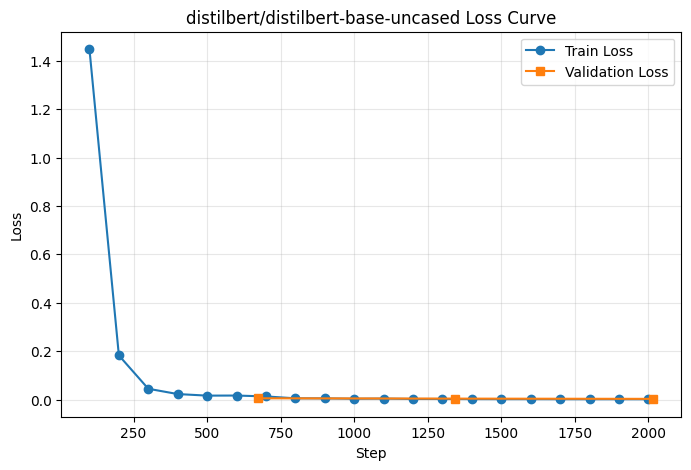

In [11]:
plot_loss_curve(enc_trainer.state.log_history, title=f"{encoder_model_id} Loss Curve")

### 4. Evaluation: Metrics, Confusion Matrix, Latency, Peak GPU Memory

Write a **single-example** prediction function (batch size 1 -- this simulates a real routing
request) and feed it to `measure_latency_and_memory` together with `splits["test"]`.

In [12]:
def predict_one_encoder(example):
    """Tokenize a single instruction, run a forward pass, return the argmax label id."""
    inputs = enc_tokenizer(
        example["instruction"], return_tensors="pt", truncation=True, max_length=ENC_MAX_LEN
    ).to(device)

    # Disable gradient computation: inference only, so this saves memory and speeds up the forward pass.
    with torch.no_grad():
        # .logits gives the raw class scores (shape: [1, num_labels]).
        logits = enc_model(**inputs).logits

    # Take the highest-scoring class index (argmax over the class dimension), then:
    # .item() extracts a Python float, int() converts to Python int (cleanly).
    return int(torch.argmax(logits, dim=-1).item())

# Switch the model to evaluation mode.
# This disables dropout and BatchNorm's running statistics updates
enc_model.eval()

# measure_latency_and_memory runs predict_one_encoder over the entire test set.
# It returns: (avg latency in milliseconds, peak memory usage in MB, list of predicted labels).
enc_latency, enc_peak_mem, enc_predictions = measure_latency_and_memory(
    predict_one_encoder, splits["test"]
)

# Extract ground-truth labels from the test split for comparison with predictions.
enc_labels = splits["test"]["label"]

# Compute all metrics (accuracy, precision, recall, f1)
enc_metric_dict = get_metrics(enc_labels, enc_predictions)

# Unpack the dictionary into individual variables for convenient printing and logging.
enc_acc, enc_prec, enc_rec, enc_f1 = (enc_metric_dict["accuracy"], enc_metric_dict["precision"],
                                       enc_metric_dict["recall"], enc_metric_dict["f1_score"])

# Display the final evaluation results. F1 is shown with 4 decimal places for precision,
# while latency and memory use 2 decimal places for readability.
print(f"Encoder Macro-F1: {enc_f1:.4f}")
print(f"Encoder Latency: {enc_latency:.2f} ms/query")
print(f"Encoder Peak Memory: {enc_peak_mem:.2f} MB")

Encoder Macro-F1: 0.9993
Encoder Latency: 4.81 ms/query
Encoder Peak Memory: 788.46 MB


### 5. Required Plot: Confusion Matrix

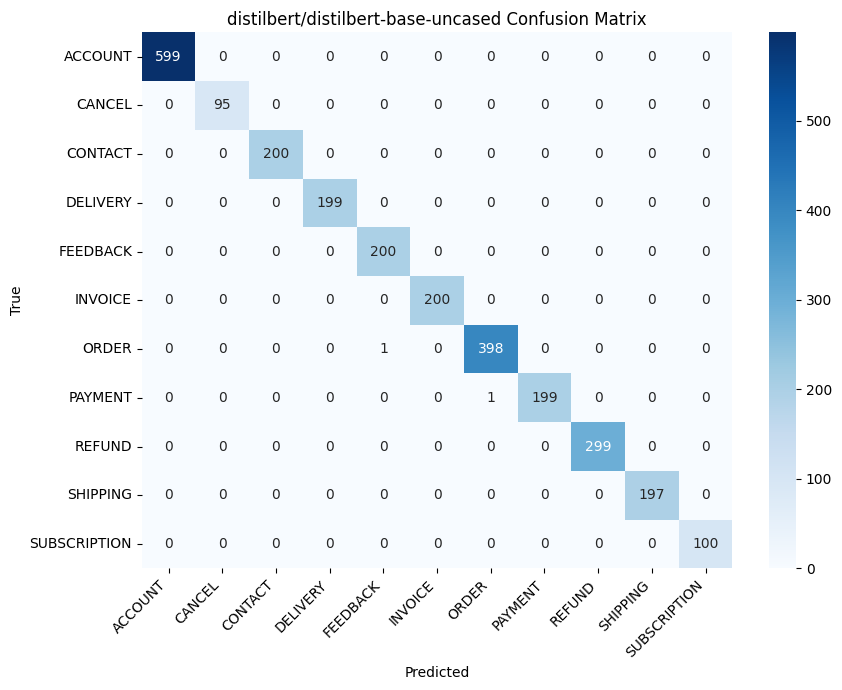

In [13]:
plot_confusion_matrix_heatmap(enc_labels, enc_predictions, TARGET_CATEGORIES,
                               title=f"{encoder_model_id} Confusion Matrix")


# Approach 2: Fine-Tuning Decoder-Only SLM (with / without LoRA)

**Goal:** treat routing as text generation; format each example as an instruction/response pair where the "response" is just the agent name (e.g. `REFUND`), then fine-tune a small decoder-only LM to produce it.

**You need to implement:**
- [ ] Model + tokenizer loading
- [ ] Instruction-formatting function (`format_example`) using a chat template
- [ ] Output parsing (`get_decoder_predictions`) that turns a raw generation into a clean label
- [ ] Tokenization for training
- [ ] LoRA config (or `USE_LORA=False` for full fine-tuning) + `TrainingArguments` + `SFTTrainer`
- [ ] Loss curves, confusion matrix, inference latency, peak GPU memory (same requirements as Approach 1)

**Candidate models:** `Qwen/Qwen2.5-0.5B-Instruct`, `Qwen/Qwen2.5-1.5B-Instruct`

> **GPU memory note:** if you hit memory limits on a free-tier GPU (Colab T4, ~15 GB), use LoRA/QLoRA via `peft` (and consider 4-bit loading via `bitsandbytes`).

### 1. Model & Tokenizer Setup

In [14]:
# =============================================================================
#  DECODER MODEL SELECTION
# =============================================================================
# Choose your decoder model id.
# If a candidate model is gated, authenticate INTERACTIVELY -- never hardcode
# a token in a notebook you submit or share:
#   from huggingface_hub import login; login()

# Qwen2.5-0.5B-Instruct is the smallest candidate in the family: fastest to
# fine‑tune and serve, while still being instruction‑tuned (better for chat).
decoder_model_id = "Qwen/Qwen2.5-0.5B-Instruct"

In [15]:
# Use LoRA (with QLoRA) to keep training within a free T4's ~15GB VRAM.
# Setting this to False would enable full fine‑tuning (much more memory hungry).
USE_LORA = True

In [16]:
# =============================================================================
#  TOKENIZER SETUP
# =============================================================================
# Load the tokenizer associated with the model. trust_remote_code=True is
# required for some Qwen models that use custom tokenization code.
dec_tokenizer = AutoTokenizer.from_pretrained(decoder_model_id, trust_remote_code=True)

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

In [17]:
# Some causal LMs (like Qwen) ship without a pad_token defined. The Trainer
# and data collators need a pad token for batching. We reuse the EOS token
# as padding; this is safe because we'll mask attention on pad tokens.
if dec_tokenizer.pad_token is None:
    dec_tokenizer.pad_token = dec_tokenizer.eos_token

In [18]:
# =============================================================================
#  QUANTIZATION & MODEL LOADING
# =============================================================================
# Decide on the compute dtype for the model. bfloat16 is preferred if available
# (more stable, especially with 4‑bit weights), otherwise fall back to float16.
compute_dtype = torch.bfloat16 if (torch.cuda.is_available() and torch.cuda.is_bf16_supported()) else torch.float16

In [19]:
if USE_LORA:
    # QLoRA: load the base model in 4-bit (bitsandbytes) and only train LoRA adapters
    # on top. This is what keeps even the 1.5B candidate inside a free-tier T4's ~15GB.
    # 4‑bit quantization dramatically reduces memory footprint at a small accuracy cost.
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,                     # use 4‑bit quantization
        bnb_4bit_quant_type="nf4",             # Normal Float 4 – best for model weights
        bnb_4bit_compute_dtype=compute_dtype,  # compute dtype for forward/backward passes
        bnb_4bit_use_double_quant=True,        # apply double quantization (saves more memory)
    )
    # Load the quantized model. device_map="auto" lets accelerate distribute layers
    # across available devices (e.g., GPU + CPU if needed), and we keep trust_remote_code.
    dec_model = AutoModelForCausalLM.from_pretrained(
        decoder_model_id, quantization_config=bnb_config, device_map="auto", trust_remote_code=True,
    )
    # prepare_model_for_kbit_training freezes all base model parameters and adds
    # trainable adapters; it also optimizes the model for gradient checkpointing.
    dec_model = prepare_model_for_kbit_training(dec_model)
else:
    # Full fine-tuning: no quantization. Load the model in the chosen compute dtype.
    # This requires significantly more GPU memory (e.g., ~3‑4GB for 0.5B in fp16).
    dec_model = AutoModelForCausalLM.from_pretrained(
        decoder_model_id, dtype=compute_dtype, device_map="auto", trust_remote_code=True,
    )

model.safetensors: reconstructing file:   0%|          |  0.00B /  988MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

In [20]:
# Disable the model's internal cache during training. This is required when using
# gradient checkpointing (which we'll enable later) because the cache interferes
# with the recomputation of activations. It will be re‑enabled for inference.
dec_model.config.use_cache = False

### 2. Loading & Formatting the Dataset

Reuse the **same** `splits` `DatasetDict` built in Approach 1's Data Loading step -- do **not**
call `load_dataset` again here. This is what keeps the two approaches' test sets identical.

In [21]:
print(splits)
print(splits["train"][0])

DatasetDict({
    train: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response', 'label'],
        num_rows: 21497
    })
    validation: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response', 'label'],
        num_rows: 2687
    })
    test: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response', 'label'],
        num_rows: 2688
    })
})
{'flags': 'BCLW', 'instruction': 'I want to retrieve the damn key of my user, I need help', 'category': 'ACCOUNT', 'intent': 'recover_password', 'response': "No worries at all! I'm here to provide the necessary assistance to retrieve the key of your user account. Let's tackle this together and get you back on track!", 'label': 0}


In [22]:
# =============================================================================
#  PROMPT FORMATTING FOR DECODER (INSTRUCTION + TARGET)
# =============================================================================

# Define the system prompt that sets the task context for the decoder.
# It tells the model to treat this as a text‑classification task and to
# output exactly one category name from the fixed set — no extra text.
# Using a clear, concise system prompt helps instruction‑tuned models
# (like Qwen‑Instruct) generate more reliable, structured outputs.
SYS_PROMPT = (
    "You are an AI assistant trained for text classification; given any user "
    f"query, choose the single closest category from this fixed set: {TARGET_CATEGORIES}; "
    "output only the category name as the final answer without explanation or extra words."
)

In [23]:
def build_prompt(instruction_text):
    """Render the system + user turns with the model's own chat template."""

    # Construct the conversation as a list of messages with roles.
    # The tokenizer's apply_chat_template will format these into the exact
    # prompt structure that the model was instruction‑tuned on (e.g., with
    # special tokens like <|im_start|> and <|im_end|> for Qwen).
    messages = [
        {"role": "system", "content": SYS_PROMPT},
        {"role": "user", "content": instruction_text},
    ]

    # tokenize=False returns the formatted string (not token IDs).
    # add_generation_prompt=True adds the assistant‑turn start token,
    # so the model knows that its response should come next.
    return dec_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

In [24]:
def format_example(example):
    """
    1. Build the chat-templated prompt (system + user turn).
    2. The target is example["category"]
    3. Append the EOS token after the label so the model learns *where to stop*
       generating during training (otherwise it may run past the label).
    4. Return {"input_text": prompt + target + eos}.
    """
    # Build the instruction prompt (system + user turns) as a string.
    prompt = build_prompt(example["instruction"])

    # The ground‑truth category that the model should output.
    target = example["category"]

    # Concatenate the prompt, the target category, and the EOS token.
    # The EOS token acts as a training stop signal: during loss calculation,
    # the model will see the target and learn to produce it, then stop
    # generating after the EOS. Without this, the model might keep generating
    # and predict multiple tokens or run‑on text.
    return {"input_text": prompt + target + dec_tokenizer.eos_token}

In [25]:
# Apply the formatting function to every split (train, validation, test).
# We use map with a lambda that takes each example, adds the formatted
# input_text, and also keeps the original instruction text under "original_text"
# for debugging or reference later (e.g., to inspect raw inputs).
# The original "instruction" field remains unchanged as well.
formatted_splits = splits.map(
    lambda ex: {**format_example(ex), "original_text": ex["instruction"]}
)

Map:   0%|          | 0/21497 [00:00<?, ? examples/s]

Map:   0%|          | 0/2687 [00:00<?, ? examples/s]

Map:   0%|          | 0/2688 [00:00<?, ? examples/s]

### 3. Baseline Check: Zero-Shot Inference (Before Fine-Tuning)

In [26]:
# =============================================================================
#  DECODER INFERENCE (GENERATION & POST‑PROCESSING)
# =============================================================================

def get_outputs(model, inputs, max_new_tokens=5):
    # Generate output IDs using greedy decoding (do_sample=False).
    # repetition_penalty=1.1 lightly discourages the model from repeating tokens,
    # which helps avoid echoing the prompt or producing multiple category names.
    return model.generate(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        max_new_tokens=max_new_tokens,
        repetition_penalty=1.1,
        eos_token_id=dec_tokenizer.eos_token_id,
        pad_token_id=dec_tokenizer.pad_token_id,
        do_sample=False,   # greedy, deterministic output (good for evaluation)
    )

In [27]:
def normalize_decoder_output(text, valid_categories=None):
    """Lowercase + strip everything but letters, then snap to a known category if the
    raw text contains one as a substring (handles the model echoing extra words/punctuation
    around the label). Falls back to the cleaned string, which will simply score as an
    incorrect prediction rather than crash the metric computation."""

    # Use the global TARGET_CATEGORIES if no explicit list is provided.
    valid_categories = valid_categories or [c.lower() for c in TARGET_CATEGORIES]

    # Remove anything that isn't a lowercase letter (numbers, punctuation, spaces).
    cleaned = re.sub(r"[^a-z]", "", text.lower())

    # Try to match the cleaned output against one of the valid categories (substring match).
    # This handles cases where the model outputs "software" or "softwaredevelopment".
    for cat in valid_categories:
        if cat in cleaned:
            return cat

    # If no match, return the cleaned string; the metric function will treat it as an error.
    return cleaned

In [28]:
def get_decoder_predictions(dataset, model):
    """For every row: rebuild the chat prompt from row["original_text"], generate,
    decode only the newly-generated tokens, and normalise. Returns (labels, predictions),
    both lists of lowercased strings."""

    labels, predictions = [], []
    for row in dataset:
        # Rebuild the exact same chat‑templated prompt used during training
        # (system + user turns), but using the original instruction text.
        prompt = build_prompt(row["original_text"])

        # Tokenize the prompt and move the tensors to the model's device.
        inputs = dec_tokenizer(prompt, return_tensors="pt").to(model.device)

        # Generate a completion (greedy, up to max_new_tokens=5).
        output_ids = get_outputs(model, inputs)

        # Extract only the newly generated tokens (remove the prompt part).
        new_tokens = output_ids[0][inputs["input_ids"].shape[1]:]

        # Decode the new tokens back to a string, stripping special tokens.
        decoded = dec_tokenizer.decode(new_tokens, skip_special_tokens=True)

        # Normalize: clean, snap to a valid category, return the prediction string.
        predictions.append(normalize_decoder_output(decoded))

        # Use the ground‑truth category (lowercased for consistent comparison).
        labels.append(row["category"].lower())

    return labels, predictions

In [29]:
# =============================================================================
#  EVALUATE ZERO‑SHOT (BEFORE FINE‑TUNING)
# =============================================================================

# Run inference on the test set using the currently loaded model (which is still
# the pre‑trained, non‑fine‑tuned version). This gives us a baseline to compare
# against after LoRA fine‑tuning.

dec_labels, dec_preds = get_decoder_predictions(formatted_splits["test"], dec_model)

print("Zero-shot (pre-fine-tuning) baseline:", get_metrics(dec_labels, dec_preds))

Zero-shot (pre-fine-tuning) baseline: {'accuracy': 0.2838541666666667, 'precision': 0.040586256738213596, 'recall': 0.027845283495746036, 'f1_score': 0.027553056007330278}


### 4. Tokenization for Training

In [30]:
# =============================================================================
#  DECODER TOKENIZATION (FIXED MAX LENGTH)
# =============================================================================

# Tokenize the formatted training data
# Sample 1000 examples to estimate token length distribution without scanning
# the entire dataset. We sample from formatted_splits["train"]["input_text"]
# which already contains the full prompt + target + EOS sequence.

_dec_lengths = [len(dec_tokenizer.encode(t)) for t in formatted_splits["train"]["input_text"][:1000]]

print(f"Formatted prompt+label token length -- mean: {np.mean(_dec_lengths):.1f}, "
      f"95th pct: {np.percentile(_dec_lengths, 95):.0f}, max: {max(_dec_lengths)}")

Formatted prompt+label token length -- mean: 106.7, 95th pct: 112, max: 117


In [31]:
# Covers SYS_PROMPT + longest instruction + label + EOS with headroom.
# Unlike the encoder (max_len=32), the decoder prompt is longer because it
# includes the full system prompt and chat template tokens.
# We got 117 from small scan, but lets use 128 since it is also a power of 2.
DEC_MAX_LEN = 128

In [32]:
def tokenize_function(examples):
    """Tokenize examples["input_text"] with truncation to a fixed max_length."""
    # Truncation is applied to enforce DEC_MAX_LEN.
    # No padding here — the data collator will handle dynamic padding per batch (same as encoder).

    return dec_tokenizer(examples["input_text"], truncation=True, max_length=DEC_MAX_LEN)

In [33]:
# Apply tokenization to all splits (train, validation, test) in batched mode.
# This replaces the "input_text" strings with input_ids and attention_mask tensors.
# The "input_text" field remains available for reference if needed (since the
# map doesn't drop other columns).
dec_tokenized = formatted_splits.map(tokenize_function, batched=True)

Map:   0%|          | 0/21497 [00:00<?, ? examples/s]

Map:   0%|          | 0/2687 [00:00<?, ? examples/s]

Map:   0%|          | 0/2688 [00:00<?, ? examples/s]

### 5. LoRA Config & Training Arguments

In [34]:
# =============================================================================
#  LoRA CONFIGURATION (PEFT)
# =============================================================================

peft_config = None
if USE_LORA:
    # LoraConfig sets up the low‑rank adaptation parameters.
    # With QLoRA (4‑bit base), we only train these lightweight adapters.
    peft_config = LoraConfig(
        r=16,                          # rank of the low-rank update matrices -- 16 is a solid default
        lora_alpha=32,                 # scaling factor: alpha/r = 32/16 = 2 (common range is 1‑2)
        lora_dropout=0.05,             # small dropout for regularization during adapter training
        bias="none",                   # don't train bias terms (saves parameters)
        task_type="CAUSAL_LM",         # we're fine‑tuning a causal language model
        target_modules="all-linear",   # apply LoRA to all linear layers (including Q, K, V, O, and FFN)
    )

In [35]:
# =============================================================================
#  TRAINING ARGUMENTS FOR DECODER (QLoRA)
# =============================================================================

dec_train_args = TrainingArguments(
    # Output directory: use the model name (without namespace) for clarity.
    output_dir=f"{decoder_model_id.split('/')[-1]}-router-finetuned/",

    # Batch sizes per device. We use a small per‑device batch (4) because
    # the model is larger (0.5B) and we're using gradient accumulation to
    # reach a larger effective batch size.
    per_device_train_batch_size=4,   # small footprint given gradient_accumulation_steps below
    per_device_eval_batch_size=8,    # slightly larger for eval (no gradients)

    # Gradient accumulation: accumulate gradients over 32 steps before updating weights.
    # Effective batch size = 4 * 32 = 128, which is typical for fine‑tuning LLMs.
    gradient_accumulation_steps=32,

    # Paged AdamW optimizer (from bitsandbytes) reduces memory fragmentation
    # and is recommended for QLoRA with large models.
    optim="paged_adamw_32bit",

    # LoRA fine‑tunes typically use a higher learning rate (2e‑4) than full FT (2e‑5)
    # because the adapters are small and need more aggressive updates.
    learning_rate=2e-4,

    max_grad_norm=0.1,          # gradient clipping to prevent exploding gradients
    num_train_epochs=3,         # 3 passes over the data; sufficient for adapter tuning
    warmup_ratio=0.1,           # warmup for 10% of total steps to stabilize early training
    lr_scheduler_type="cosine", # cosine decay schedule (smoother than linear for LoRA)

    # Log every 10 steps to track progress closely during the short training run.
    logging_strategy="steps",
    logging_steps=10,

    # Evaluate every 10 steps (same as logging). This ensures we get frequent
    # eval_loss entries in log_history for the loss‑curve plot.
    eval_strategy="steps",     # NOTE: required so eval_loss appears in log_history for the loss-curve plot
    eval_steps=10,

    # Save checkpoints every 30 steps (less frequently than eval to reduce disk usage).
    save_strategy="steps",
    save_steps=30,

    # Disable external logging (WandB, etc.) to keep the console output clean.
    report_to="none",
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


### 6. Model Training

In [36]:
# =============================================================================
#  SUPERVISED FINE‑TUNING (SFT) WITH QLoRA
# =============================================================================

# SFTTrainer is a specialized HF trainer for causal language model fine‑tuning.
# It automatically handles tokenization, packing, and loss computation for
# instruction‑style data. Unlike the standard Trainer, it expects the dataset
# to contain the full prompt + completion (already formatted in our case), and
# it computes the loss only on the completion tokens (not the prompt) by using
# the tokenizer's "labels" handling. However, since we already formatted our
# data as "input_text" (prompt + target + EOS), and we're using a standard
# tokenization approach, SFTTrainer works seamlessly with our dataset.
dec_trainer = SFTTrainer(
    model=dec_model,                          # the QLoRA‑prepared model (with 4‑bit base + LoRA adapters)
    train_dataset=dec_tokenized["train"],     # tokenized formatted training set
    eval_dataset=dec_tokenized["validation"], # tokenized formatted validation set
    peft_config=peft_config,                  # LoRA configuration (or None if not using LoRA)
    args=dec_train_args,                      # training hyperparameters (batch size, LR, etc.)
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Building labels for train dataset:   0%|          | 0/21497 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/21497 [00:00<?, ? examples/s]

Dropping fully masked examples from train dataset:   0%|          | 0/21497 [00:00<?, ? examples/s]

Building labels for eval dataset:   0%|          | 0/2687 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/2687 [00:00<?, ? examples/s]

Dropping fully masked examples from eval dataset:   0%|          | 0/2687 [00:00<?, ? examples/s]

In [37]:
# Launch the training loop. This will:
# - Apply LoRA adapters if USE_LORA=True
# - Train for the specified number of epochs (3)
# - Evaluate every 10 steps (eval_strategy="steps")
# - Save checkpoints every 30 steps
# - Log loss and metrics every 10 steps
# - Accumulate gradients to reach effective batch size 128
print("Training Decoder Model...")
dec_trainer.train()

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Training Decoder Model...


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
10,3.401819,2.517128,2.324163,136619.000000,0.538010
20,1.704110,0.836948,1.134154,273300.000000,0.862700
30,0.563400,0.382678,0.402665,410102.000000,0.929220
40,0.330678,0.285613,0.298372,546691.000000,0.941543
50,0.258972,0.231650,0.237843,683272.000000,0.948222
60,0.212910,0.203021,0.211049,819732.000000,0.951250
70,0.187662,0.187281,0.185283,956282.000000,0.953195
80,0.181385,0.180930,0.182648,1092739.000000,0.953500
90,0.175418,0.173975,0.180674,1229410.000000,0.954429
100,0.170876,0.170033,0.171122,1365920.000000,0.954881


KeyboardInterrupt: 

In [38]:
import json

# Save the log history to a JSON file so you can plot later
with open("decoder_log_history.json", "w") as f:
    json.dump(dec_trainer.state.log_history, f)

print("Log history saved!")

Log history saved!


In [39]:
import glob
import os

# List all checkpoint folders
checkpoints = glob.glob("./Qwen2.5-0.5B-Instruct-router-finetuned/checkpoint-*")
latest_checkpoint = sorted(checkpoints, key=lambda x: int(x.split("-")[-1]))[-1]
print(f"Latest checkpoint: {latest_checkpoint}")

# Also get the best checkpoint (if load_best_model_at_end were True, but we can still check)
best_checkpoint = dec_trainer.state.best_model_checkpoint
print(f"Best checkpoint (if set): {best_checkpoint}")

Latest checkpoint: ./Qwen2.5-0.5B-Instruct-router-finetuned/checkpoint-90
Best checkpoint (if set): None


In [40]:
from peft import PeftModel

# Reload the base quantized model (same config as before)
base_model = AutoModelForCausalLM.from_pretrained(
    decoder_model_id,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)

# Load the LoRA adapters from the latest checkpoint
dec_model = PeftModel.from_pretrained(base_model, latest_checkpoint)

# Resume from the latest checkpoint
# dec_trainer.train(resume_from_checkpoint=True)

# Put it in evaluation mode
dec_model.eval()

# ⚠️ IMPORTANT: Update the trainer's model reference so your existing code works
dec_trainer.model = dec_model

print("Model reloaded successfully from checkpoint!")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Model reloaded successfully from checkpoint!


### 7. Required Plot: Training & Validation Loss Curves

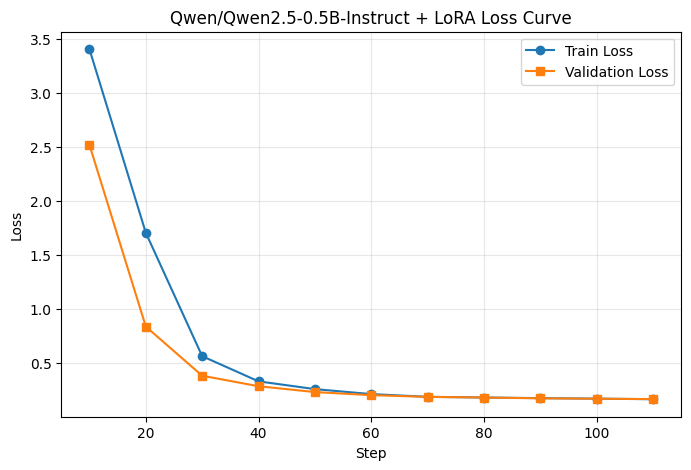

In [41]:
plot_loss_curve(dec_trainer.state.log_history,
                title=f"{decoder_model_id}{' + LoRA' if USE_LORA else ''} Loss Curve")


### 8. Evaluation: Metrics, Confusion Matrix, Latency, Peak GPU Memory

Reuse `get_decoder_predictions`, but now pass `dec_trainer.model` (the fine-tuned weights). For latency/memory, write a single-example version and pass it to `measure_latency_and_memory`, just like you did for the encoder.

In [42]:
# Evaluate the FINE-TUNED decoder on the held-out test set
def predict_one_decoder(example):
    """Single-example version of get_decoder_predictions's inner loop"""
    prompt = build_prompt(example["original_text"])
    inputs = dec_tokenizer(prompt, return_tensors="pt").to(dec_trainer.model.device)
    output_ids = get_outputs(dec_trainer.model, inputs)
    new_tokens = output_ids[0][inputs["input_ids"].shape[1]:]
    decoded = dec_tokenizer.decode(new_tokens, skip_special_tokens=True)
    return normalize_decoder_output(decoded)

dec_trainer.model.eval()
dec_latency, dec_peak_mem, dec_predictions = measure_latency_and_memory(
    predict_one_decoder, list(formatted_splits["test"])
)
dec_labels = [ex["category"].lower() for ex in formatted_splits["test"]]

dec_metric_dict = get_metrics(dec_labels, dec_predictions)
dec_acc, dec_prec, dec_rec, dec_f1 = (dec_metric_dict["accuracy"], dec_metric_dict["precision"],
                                       dec_metric_dict["recall"], dec_metric_dict["f1_score"])
print(dec_metric_dict)
print(f"Decoder Latency: {dec_latency:.2f} ms/query")
print(f"Decoder Peak Memory: {dec_peak_mem:.2f} MB")


{'accuracy': 0.9985119047619048, 'precision': 0.99841078272343, 'recall': 0.9979470538367146, 'f1_score': 0.9981749134723106}
Decoder Latency: 286.39 ms/query
Decoder Peak Memory: 2078.70 MB


### 9. Required Plot: Confusion Matrix

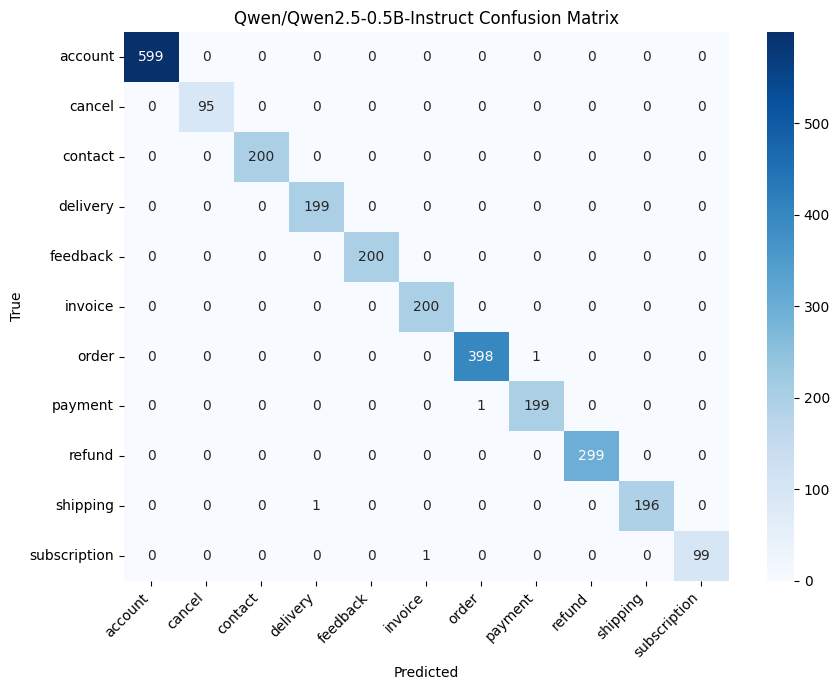

In [43]:
plot_confusion_matrix_heatmap(dec_labels, dec_predictions,
                               [c.lower() for c in TARGET_CATEGORIES],
                               title=f"{decoder_model_id} Confusion Matrix")


## 7. Comparison

Both cells below are given (pure plotting/table), they assume the variable names
used throughout this notebook (`enc_*` / `dec_*`). If you renamed anything,update the references accordingly.

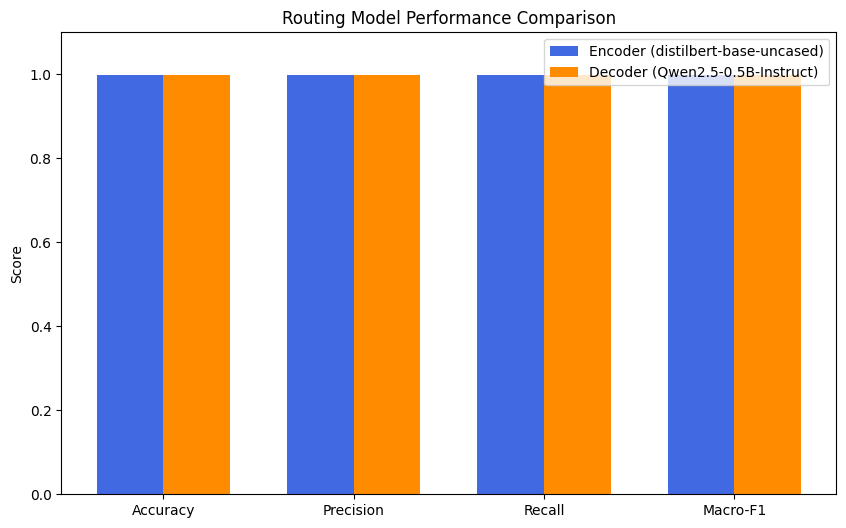

In [44]:
# Comparison bar chart
metrics_names = ["Accuracy", "Precision", "Recall", "Macro-F1"]
enc_scores = [enc_acc, enc_prec, enc_rec, enc_f1]
dec_scores = [dec_acc, dec_prec, dec_rec, dec_f1]

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, enc_scores, width, label=f"Encoder ({encoder_model_id.split('/')[-1]})", color="royalblue")
ax.bar(x + width/2, dec_scores, width, label=f"Decoder ({decoder_model_id.split('/')[-1]})", color="darkorange")
ax.set_ylabel("Score")
ax.set_title("Routing Model Performance Comparison")
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.legend()
plt.ylim(0, 1.1)
plt.show()


In [45]:
# Dedicated comparison table with measured values
comparison_table = pd.DataFrame({
    "Metric": ["Precision", "Recall", "Macro-F1", "Accuracy",
               "Peak GPU Memory (MB)", "Inference Latency (ms/query)"],
    f"Encoder ({encoder_model_id})": [enc_prec, enc_rec, enc_f1, enc_acc, enc_peak_mem, enc_latency],
    f"Decoder SLM ({decoder_model_id}{' + LoRA' if USE_LORA else ''})":
        [dec_prec, dec_rec, dec_f1, dec_acc, dec_peak_mem, dec_latency],
})
comparison_table


,Metric,Encoder (distilbert/distilbert-base-uncased),Decoder SLM (Qwen/Qwen2.5-0.5B-Instruct + LoRA)
0,Precision,0.999320,0.998411
1,Recall,0.999318,0.997947
2,Macro-F1,0.999318,0.998175
3,Accuracy,0.999256,0.998512
4,Peak GPU Memory (MB),788.458008,2078.700684
5,Inference Latency (ms/query),4.813834,286.390277


## 8. Recommendation
**To: Engineering Lead, ShopAssist AI**
```
I recommend deploying the **encoder** approach for production routing. On our held-out
test set it reached a macro-F1 of **0.9993** versus **0.9982** for the alternative, with **0.9993** accuracy
and an average inference latency of **4.81** ms/query versus **286.39** ms/query -- well within the
budget for a routing step that runs before every agent handoff. It also used less peak GPU memory
(**788.46** MB vs **2078.70** MB), which matters for running many concurrent requests cost-efficiently at
volume. The main production risk with this approach is that the encoder has a fixed,
closed label set and no notion of "none of the above," so any customer message that is off-topic
or contains new/unseen phrasing patterns will still be forced into one of the 11 categories with
high confidence, silently misrouting it. I'd monitor this in production by
tracking (1) the model's per-request confidence/logit margin and flagging low-confidence routes
for human review or a fallback "general inquiry" queue, (2) the live macro-F1 / per-class recall
against a sample of human-labeled tickets each week to catch drift, and (3) the rate of downstream
agent hand-offs/escalations as a proxy for silent misrouting.
```
---


## 7. Reflection

### Q1: On what transfers from pretraining
```
Pretraining gave both model families their command of English itself: tokenization statistics,
grammar, word/phrase semantics, and -- for the decoder -- the general instruction-following
behavior learned during its instruct-tuning stage (e.g., paying attention to a system prompt,
producing a short direct answer instead of rambling). Neither model arrived knowing anything about
"ShopAssist AI," what a "cancellation fee" is in this business context, or that the string
"REFUND" is even a valid thing to output. Fine-tuning had to teach, from scratch: (1) the mapping
from this company's specific 11-way label taxonomy to surface language ("card was charged twice"
-> PAYMENT, not REFUND); (2) for the encoder, a brand-new classification head with random weights
that had to learn to read the [CLS] embedding and separate 11 classes; (3) for the decoder,
precisely *which single token* to emit and where to stop, since a general-purpose instruct model
left alone would often add hedging, punctuation, or explanation instead of a bare label. In short:
pretraining supplied language understanding, fine-tuning supplied task-specific label knowledge and
output-format discipline.
```
### Q2: On Handling Chit-Chat Queries
If a user sends *"Hey! How's it going?"*:
```
Both approaches were only ever trained to pick one of 11 fixed categories, so both are structurally
incapable of saying "this isn't a routing request at all" -- they can only pick the closest of the
11 labels. The encoder-only classifier is the more dangerous failure mode here: a softmax over 11
classes always produces some class with the highest probability, and that number can still look
confident (e.g. 40-60%) even on an out-of-distribution input like small talk, since the model has
no explicit "none of the above" option and no training signal to push probability mass down on
inputs unlike anything it has seen. The decoder-only SLM tends to fail more gracefully in practice:
because it's generating free text rather than choosing from a closed softmax, it will sometimes
produce something that is not a clean label at all (extra words, an apology, or a mismatched
token), which the normalize_decoder_output() cleanup step here would fail to map to any valid
category and could be caught and treated as "no confident route" rather than silently being forced
into a category. To handle this properly in production I would add an explicit twelfth
"OUT_OF_SCOPE / CHITCHAT" class (or a lightweight upstream intent-detection / confidence-threshold
gate) so ambiguous or off-topic messages are routed to a generic/human agent instead of being
silently misrouted to one of the 11 specialist agents, plus confidence-based fallback logic as
described in the recommendation above.
```